scratch to put in superlinear evolution into 009.016 as check

In [1]:
from LIMxCMBL.init import *
from LIMxCMBL.kernels import *
from LIMxCMBL.noise import *

import sys

Lambda_idx = 8
nbins = 100
curr_bin = 13
zmin = 2.4
zmax = 3.4
line_str = 'CO'


Lambda = Lambdas[Lambda_idx]
chimin = ccl.comoving_angular_distance(cosmo, 1/(1+zmin))
chimax = ccl.comoving_angular_distance(cosmo, 1/(1+zmax))

m_for_LO = 0
while(m_for_LO * 2 * np.pi / (chimax - chimin) < Lambda):
    m_for_LO += 1
m_for_LO -= 1
print('m for low pass is', m_for_LO)

chi_bin_edges = np.linspace(chimin*(1+1e-8), chimax*(1 - 1e-8), nbins + 1)
chi_bin_centers = (chi_bin_edges[1:] + chi_bin_edges[:-1])/2
dchi_binned = np.mean(np.diff(chi_bin_edges))

/home/users/delon/.local/lib/python3.9/site-packages/astropy/units/quantity.py:673: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


m for low pass is 0


In [5]:
oup_fname = '/scratch/users/delon/LIMxCMBL/IHiKappa/'
oup_fname += '%s_IHik_zmin_%.1f_zmax_%.1f_idx_%d_dblquad_n_bins_%d_curr_%d.npy'%(line_str,
                                                                                 zmin, 
                                                                                 zmax, 
                                                                                 Lambda_idx, 
                                                                                 nbins, 
                                                                                 curr_bin)

# get CMB lensing component
from LIMxCMBL.kernels import get_f_Kkappa
f_WkD = get_f_Kkappa()

from LIMxCMBL.cross_spectrum import *
ClKK = d_chib_integral(f_WkD, f_WkD) #[Mpc]^2

kernels = {}
kernels['CII'] = np.array(KI)
kernels['CO'] = np.array(KI_CO)
kernels['Lya'] = np.array(KI_Lya)
kernels['HI'] = np.array(KI_HI)


_KI = kernels[line_str]

In [6]:
import matplotlib.pyplot as plt

putting in superlinear_evol


(5858.141794387897, 6880.17427449672)

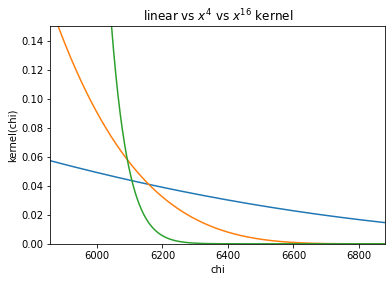

In [19]:
###### SUPERLINEAR
supLin = False
if(len(sys.argv) > 7 and sys.argv[-1] == 'sL'):
    supLin = True
supLin = True  ##TMP
plt.figure(facecolor='w')
if(supLin):
    tmp_idxs = np.where((chis >= chimin) & (chis <= chimax))
    print('putting in superlinear_evol')
    plt.plot(chis[tmp_idxs], _KI[tmp_idxs])
    
    mean_KI = np.mean(_KI[tmp_idxs])
    
#     #constraints
#     #supLin(chimax) = 0
#     #1/L int_chimin^chimax supLin(chi) = mean_KI
    
    _a = (5 * mean_KI)**(1/4)/(chimax - chimin)
    _b = (5 * mean_KI)**(1/4) * chimax / (chimax - chimin)
    _supLin_KI = (_a * chis - _b)**4
    plt.plot(chis[tmp_idxs], _supLin_KI[tmp_idxs])

    
    #constraints
    #supLin(chimax) = 0
    #1/L int_chimin^chimax supLin(chi) = mean_KI
    _a = 17 * mean_KI * chimax / (chimax - chimin)**(17)
    _supLin_KI = _a * (chis - chimax)**16
    
    
    plt.plot(chis[tmp_idxs], _supLin_KI[tmp_idxs])
    
#     _KI = _supLin_KI
    oup_fname = '/scratch/users/delon/LIMxCMBL/IHiKappa/'
    oup_fname += '%s_IHik_zmin_%.1f_zmax_%.1f_idx_%d_dblquad_n_bins_%d_curr_%d_superlinear.npy'%(line_str,
                                                                                     zmin, 
                                                                                     zmax, 
                                                                                     Lambda_idx, 
                                                                                     nbins, 
                                                                                     curr_bin)

#################
plt.title('linear vs $x^4$ vs $x^{16}$ kernel')
plt.xlabel('chi')
plt.ylabel('kernel(chi)')
plt.ylim(0, 0.15)
plt.xlim(chimin, chimax)